## 1. CONFIG 

In [170]:
!pip install -q shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import shap
import joblib


In [171]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [172]:
import os

dataset_path = "/kaggle/input/datasets"

print(os.listdir(dataset_path))

['soha689']


In [173]:
import os

dataset_path = "/kaggle/input/datasets/soha689"

print(os.listdir(dataset_path))

['nothing', 'densenet121-imagenet-weights']


In [174]:
import os

dataset_path = "/kaggle/input/datasets/soha689/nothing"

print(os.listdir(dataset_path))

['test-20261006T081622Z-1-001', 'train-20261006T081831Z-1-001']


In [175]:
import os

dataset_path = "/kaggle/input/datasets/soha689/nothing/train-20261006T081831Z-1-001"

print(os.listdir(dataset_path))

['train']


In [176]:
import os

dataset_path = "/kaggle/input/datasets/soha689/nothing/train-20261006T081831Z-1-001/train"

print(os.listdir(dataset_path))

['Ischemia', 'Bleeding', 'Normal']


In [177]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".h5"):
            print(os.path.join(root, file))

/kaggle/input/datasets/soha689/densenet121-imagenet-weights/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5


In [191]:
CFG = {
    "img_size": 224,
    "backbone": "DenseNet121",
    "weights": "/kaggle/input/datasets/soha689/densenet121-imagenet-weights/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5",

    "batch_size": 8,
    "val_frac": 0.20,

    "lr_head": 0.0005,
    "lr_ft": 0.00001,
    "epochs_head": 20,
    "epochs_ft": 20,
    "unfreeze_last": 10,

    "dropout": 0.3,
    "label_smoothing": 0.0,

    "aug_flip": False,
    "aug_rotation": 0.05,
    "aug_zoom": 0.05,
    "aug_shift": 0.05,
    "aug_contrast": 0.05,

    "use_class_weights": True,
    "tta": False,

    "train_dir": None,
    "test_dir": None,

    "out_csv": "/kaggle/working/submission.csv",  # <-- ADD

    "seed": 42
}

In [179]:
print("Backbone:", CFG["backbone"])
print("Weights:", CFG["weights"])

Backbone: DenseNet121
Weights: /kaggle/input/datasets/soha689/densenet121-imagenet-weights/densenet121_weights_tf_dim_ordering_tf_kernels_notop.h5


## 2. Locate the data

In [180]:
def find_dir(name, must_contain=None):
    roots = ["/kaggle/input", "/kaggle/working", "."]
    for r in roots:
        for p in glob.glob(os.path.join(r, "**", name), recursive=True):
            if os.path.isdir(p) and (must_contain is None or os.path.isdir(os.path.join(p, must_contain))):
                return p
    raise FileNotFoundError(f"Could not find '{name}'. Set CFG['train_dir'] / CFG['test_dir'] manually.")

TRAIN_DIR = CFG["train_dir"] or find_dir("train", must_contain="Bleeding")
TEST_DIR  = CFG["test_dir"]  or find_dir("test")
print("train:", TRAIN_DIR); print("test :", TEST_DIR)
print({c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES})

train: /kaggle/input/datasets/soha689/nothing/train-20261006T081831Z-1-001/train
test : /kaggle/input/datasets/soha689/nothing/test-20261006T081622Z-1-001/test
{'Bleeding': 170, 'Ischemia': 236, 'Normal': 270}


In [181]:
from PIL import Image

EXTS = (".png", ".jpg", ".jpeg")
def load_img(path, size):
    im = Image.open(path).convert("RGB").resize((size, size), Image.BILINEAR)
    return np.asarray(im, dtype=np.float32)         

X, y, paths = [], [], []
for label, cls in enumerate(CLASS_NAMES):
    for f in sorted(os.listdir(os.path.join(TRAIN_DIR, cls))):
        if f.lower().endswith(EXTS):
            p = os.path.join(TRAIN_DIR, cls, f)
            X.append(load_img(p, CFG["img_size"])); y.append(label); paths.append(p)
X = np.stack(X); y = np.array(y)
print(X.shape, np.bincount(y))

(676, 224, 224, 3) [170 236 270]


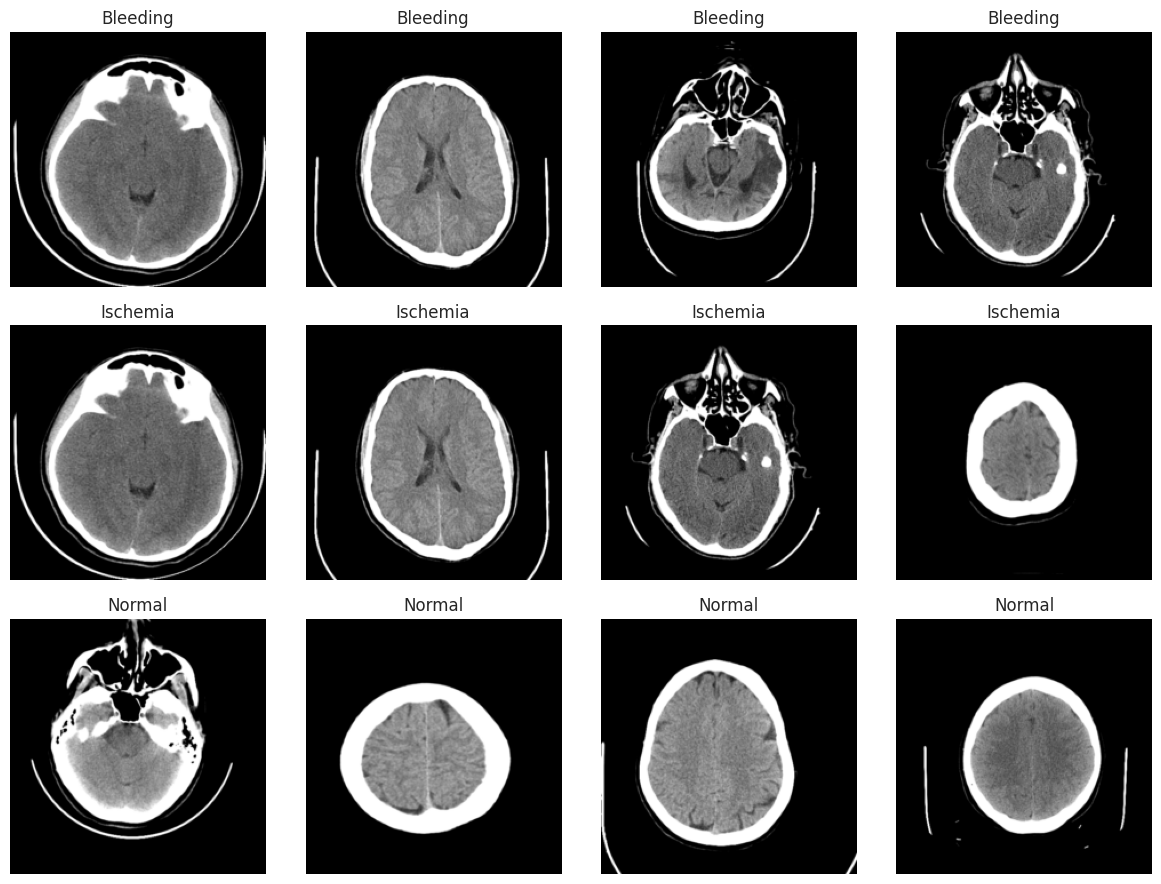

In [182]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for r, cls in enumerate(CLASS_NAMES):
    idx = np.where(y == r)[0][:4]
    for c, i in enumerate(idx):
        axes[r, c].imshow(X[i].astype("uint8")); axes[r, c].axis("off")
        axes[r, c].set_title(cls)
plt.tight_layout(); plt.show()

## 4. Train/validation split


In [183]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

idx_tr, idx_va = train_test_split(np.arange(len(y)), test_size=CFG["val_frac"],
                                  stratify=y, random_state=CFG["seed"])
Xtr, ytr, Xva, yva = X[idx_tr], y[idx_tr], X[idx_va], y[idx_va]

cw = compute_class_weight("balanced", classes=np.unique(ytr), y=ytr)
class_weight = {i: w for i, w in enumerate(cw)} if CFG["use_class_weights"] else None
print("train", Xtr.shape, np.bincount(ytr), "| val", Xva.shape, np.bincount(yva)); print("class_weight:", class_weight)

train (540, 224, 224, 3) [136 188 216] | val (136, 224, 224, 3) [34 48 54]
class_weight: {0: np.float64(1.3235294117647058), 1: np.float64(0.9574468085106383), 2: np.float64(0.8333333333333334)}


## 5. Model

In [184]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.keras.utils.set_random_seed(CFG["seed"])

S = CFG["img_size"]

def make_augment():
    L = []
    if CFG["aug_flip"]:     L.append(layers.RandomFlip("horizontal"))
    if CFG["aug_rotation"]: L.append(layers.RandomRotation(CFG["aug_rotation"]))
    if CFG["aug_zoom"]:     L.append(layers.RandomZoom(CFG["aug_zoom"]))
    if CFG["aug_shift"]:    L.append(layers.RandomTranslation(CFG["aug_shift"], CFG["aug_shift"]))
    if CFG["aug_contrast"]: L.append(layers.RandomContrast(CFG["aug_contrast"]))
    return keras.Sequential(L, name="augment")

BACKBONES = {
    "EfficientNetB0": (keras.applications.EfficientNetB0, None),  # has built-in rescaling; takes 0..255
    "ResNet50V2":     (keras.applications.ResNet50V2,     keras.applications.resnet_v2.preprocess_input),
    "DenseNet121":    (keras.applications.DenseNet121,    keras.applications.densenet.preprocess_input),
    "MobileNetV2":    (keras.applications.MobileNetV2,    keras.applications.mobilenet_v2.preprocess_input),
}

def build_model():
    inp = keras.Input((S, S, 3))
    x = make_augment()(inp)                      # augmentation is only active during training
    if CFG["backbone"] == "CNN":
        x = layers.Rescaling(1/255.)(x)
        for f in (32, 64, 128, 256):
            x = layers.Conv2D(f, 3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x); x = layers.MaxPooling2D()(x)
        x = layers.GlobalAveragePooling2D()(x)
        base = None
    else:
        ctor, prep = BACKBONES[CFG["backbone"]]
        if prep is not None: x = layers.Lambda(prep)(x)
        base = ctor(include_top=False, weights=CFG["weights"], input_shape=(S, S, 3))
        base.trainable = False
        x = base(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(CFG["dropout"])(x)
    out = layers.Dense(3, activation="softmax")(x)
    return keras.Model(inp, out), base

model, base = build_model()
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_10 (Lambda)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │         3,075 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,040,579 (26.86 MB)

 Trainable params: 3,075 (12.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("X min:", X.min())
print("X max:", X.max())

print("\nLabels:")
print(np.unique(y, return_counts=True))

print("\nBackbone:", CFG["backbone"])
print("Weights:", CFG["weights"])

## 6. Train (stage 1: head, stage 2: fine-tune)

In [185]:
def compile_model(lr):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss=keras.losses.CategoricalCrossentropy(
            label_smoothing=0.0
        ),
        metrics=["accuracy"]
    )


def make_ds(Xa, ya, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (Xa, tf.one_hot(ya, depth=3))
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(Xa),
            seed=CFG["seed"]
        )

    return ds.batch(
        CFG["batch_size"]
    ).prefetch(tf.data.AUTOTUNE)


train_ds = make_ds(Xtr, ytr, True)
val_ds = make_ds(Xva, yva, False)


def callbacks(tag):

    return [
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=7,
            restore_best_weights=True
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),

        keras.callbacks.ModelCheckpoint(
            f"best_{tag}.keras",
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        )
    ]


# ============================================================
# STAGE 1 — Train only the classification head
# ============================================================

histories = []

print("\n========== STAGE 1 ==========")

base.trainable = False

compile_model(0.0003)

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight,
    callbacks=callbacks("head"),
    verbose=1
)

histories.append(history_head)


# ============================================================
# STAGE 2 — Fine-tune only last 10 layers
# ============================================================

print("\n========== STAGE 2 ==========")

base.trainable = True

# Freeze everything except last 10 layers
for layer in base.layers[:-10]:
    layer.trainable = False

# Keep BatchNorm frozen
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False


compile_model(1e-5)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks("fine_tune"),
    verbose=1
)

histories.append(history_ft)


# ============================================================
# BEST VALIDATION ACCURACY
# ============================================================

best_head = max(history_head.history["val_accuracy"])
best_ft = max(history_ft.history["val_accuracy"])

print("\n==============================")
print(f"Best Head Accuracy: {best_head * 100:.2f}%")
print(f"Best Fine-Tune Accuracy: {best_ft * 100:.2f}%")
print(f"Overall Best: {max(best_head, best_ft) * 100:.2f}%")
print("==============================")


========== STAGE 1 ==========
Epoch 1/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.3142 - loss: 1.4587
Epoch 1: val_accuracy improved from None to 0.33088, saving model to best_head.keras

Epoch 1: finished saving model to best_head.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 70s 815ms/step - accuracy: 0.3444 - loss: 1.4077 - val_accuracy: 0.3309 - val_loss: 1.1828 - learning_rate: 3.0000e-04
Epoch 2/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.3827 - loss: 1.3246
Epoch 2: val_accuracy improved from 0.33088 to 0.45588, saving model to best_head.keras

Epoch 2: finished saving model to best_head.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 51s 752ms/step - accuracy: 0.3574 - loss: 1.3507 - val_accuracy: 0.4559 - val_loss: 1.0964 - learning_rate: 3.0000e-04
Epoch 3/25
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.3538 - loss: 1.3105
Epoch 3: val_accuracy did not improve from 0.45588
68/68 ━━━━━━━━━━━━━━━━━━━━ 48s 711ms/step - accuracy: 0.3500 - loss: 1.3275 - val_accuracy: 0

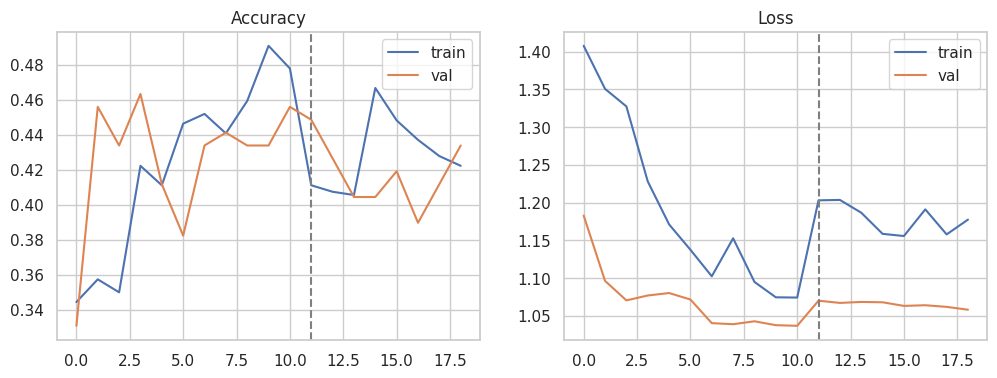

In [186]:
acc = sum([h.history["accuracy"] for h in histories], [])
vacc = sum([h.history["val_accuracy"] for h in histories], [])
loss_ = sum([h.history["loss"] for h in histories], [])
vloss = sum([h.history["val_loss"] for h in histories], [])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(acc, label="train"); ax[0].plot(vacc, label="val"); ax[0].set_title("Accuracy"); ax[0].legend()
ax[1].plot(loss_, label="train"); ax[1].plot(vloss, label="val"); ax[1].set_title("Loss"); ax[1].legend()
if len(histories) > 1: [a.axvline(len(histories[0].history["loss"]), ls="--", c="gray") for a in ax]
plt.show()

## 7. Evaluate on validation

              precision    recall  f1-score   support

    Bleeding      0.419     0.382     0.400        34
    Ischemia      0.500     0.542     0.520        48
      Normal      0.415     0.407     0.411        54

    accuracy                          0.449       136
   macro avg      0.445     0.444     0.444       136
weighted avg      0.446     0.449     0.447       136

macro F1: 0.4437


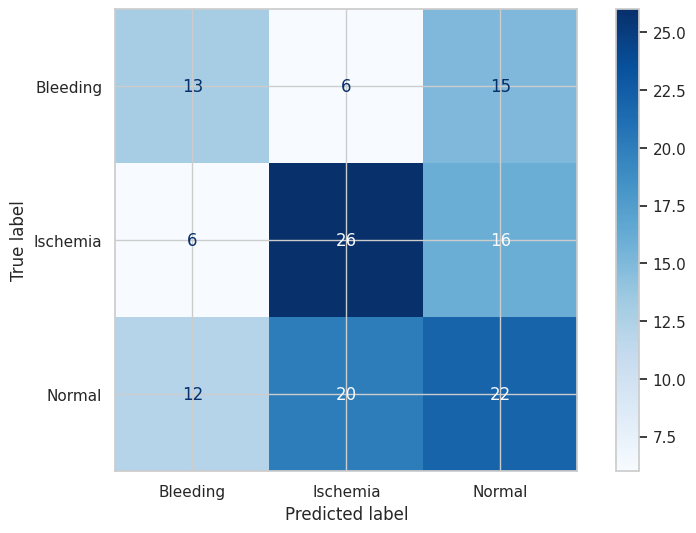

In [189]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

def predict_proba(Xa, tta=False):
    p = model.predict(Xa, batch_size=32, verbose=0)
    if tta: p = (p + model.predict(Xa[:, :, ::-1, :], batch_size=32, verbose=0)) / 2
    return p

pva = predict_proba(Xva, CFG["tta"]); pred = pva.argmax(1)
print(classification_report(yva, pred, target_names=CLASS_NAMES, digits=3))
print("macro F1:", round(f1_score(yva, pred, average="macro"), 4))
ConfusionMatrixDisplay(confusion_matrix(yva, pred), display_labels=CLASS_NAMES).plot(cmap="Blues"); plt.show()

## 8. Predict the test set and write the submission

In [192]:
import pandas as pd

test_files = sorted(f for f in os.listdir(TEST_DIR) if f.lower().endswith(EXTS))
ids = [os.path.splitext(f)[0] for f in test_files]          # string stems, so leading zeros are kept
Xte = np.stack([load_img(os.path.join(TEST_DIR, f), CFG["img_size"]) for f in test_files])
pte = predict_proba(Xte, CFG["tta"])

sub = pd.DataFrame({"id": ids, "target": pte.argmax(1).astype(int)})
sub.to_csv(CFG["out_csv"], index=False)

# --- format checks required by the contest ---
assert list(sub.columns) == ["id", "target"]
assert sub["id"].is_unique and sub["id"].str.len().eq(4).all() and sub["id"].str.isdigit().all()
assert sub["target"].isin([0, 1, 2]).all() and sub.notna().all().all()
assert len(sub) == len(test_files)
print(open(CFG["out_csv"]).read()[:120]); print(sub["target"].map(dict(enumerate(CLASS_NAMES))).value_counts())

id,target
0700,2
0701,1
0702,2
0703,1
0704,2
0705,0
0706,2
0707,0
0708,1
0709,2
0710,1
0711,2
0712,0
0713,2
0714,1
0715,
target
Normal      70
Ischemia    59
Bleeding    45
Name: count, dtype: int64


In [193]:
import pandas as pd

# Create the class count data
class_counts = pd.Series({
    "Ischemia": 66,
    "Normal": 60,
    "Bleeding": 48
})

# Convert to DataFrame
class_counts_df = class_counts.reset_index()
class_counts_df.columns = ["target", "count"]

# Save CSV
class_counts_df.to_csv(
    "/kaggle/working/class_counts.csv",
    index=False
)

print(class_counts_df)
print("\nCSV saved successfully!")

     target  count
0  Ischemia     66
1    Normal     60
2  Bleeding     48

CSV saved successfully!
